02 课程里用到的是bigram模型，我们统计counts制作概率表，制作了第一版模型；后面又从神经网络的角度出发，通过W矩阵，训练得到了第二版模型

两者的效果最终都是一样，那个W矩阵最后的结果就是趋近于counts概率表，并且我们知道，这个模型是只有一个字母输入，来输出下一个预测，因此预测的结果不算是特别好

如果我们在原有的模型上改进，试图引入更多的上下文内容(content)，来预测序列里的下一个字母，那么W尺度会急剧增长，事实上概率表的增长率达到了次方级(1个字符是27^2,2个字符就是(27*27)^2)

这样的话，矩阵的行数就会变得非常非常多，同时我们也知道，也会有很多概率很小的组合出现，可能表格的很多格子都是0，这显然不是很好的一个模型

所以 03 课程这里，我们会转向一个更好的模型 MLP (multi-layer perceptron model) 来预测下一个字母

这次采用的方法来源于论文 A Neural Probabilistic Language Model Bengio et at 2003

首先明确一点，我们在建立一个 character level(字母级别) 的语言模型，所以我们工作的角度尺度在 字母 层面，也就是 character level。原论文里使用的是17000个可能的词汇来制作 word level(单词级别)的模型，我们只是参考使用同样的模型方法，但是是在 character level 上

在论文里，他们把17000个单词映射到30(或者60维)的特征向量上，所以现在每个单词，都被embedded into (嵌入到)一个30维的向量空间，于是我们就拥有 17000 个 30维 的向量

在一开始，这些单词是随机的被初始化生成分配到向量里，然后我们在反向传播中去tune(微调)这些单词向量的嵌入表示，所以在神经网络的训练过程中，这些单词向量会在向量空间中不停的移动位置。然后你可以想象一下，就是一些可能有着相似含义的单词，最后就会出现在同样的空间附近；同时那些可能有着完全不同含义的单词就会出现在不同的空间。

论文里的模型使用的方法在其他方面和我们的差不多。他们使用一个 multi-layer neural network 来预测下一个单词，通过给予先前的单词作为输入，并且在训练过程中，他们通过最大化 log likelihood 来优化 (我们的损失函数是最小化负的log likelihood) 


来看论文里的一个例子:

比方说现在给模型输入: a dog was running in a ____ 让它预测 ____ 这里的单词

我们假设训练的数据里没有前面的 a dog was running in a 这些内容，所以按照常理来说，模型不知道下一个单词是什么，因为概率是0
 
但是通过论文里的方法，我们就有可能得到答案。尽管在训练时模型没见过 a dog was running in a 这种样子的内容，但是可能见过类似的表达，比如说: The cat is walking in the bedroom ，然后神经网络学会了 the 和 a 是比较类似的表达(因为很多地方都是可以互换的)，于是网络就有可能把 embedding for a 和 embedding for the 放在向量空间里相近的地方，所以就可以通过这个 embedding 来传递知识，于是就能生成类似的表达；

或者神经网络也有可能学会 cat 和 dog 都是动物名词，于是也把他们放在相近的向量空间位置，所以可能把 the cat is running in a room 这样的知识通过embedding传递过去，于是也能生成表达。


In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline 

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [8]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []   # X is the list of contexts, Y is the list of targets (the character that follows each context)
for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [10]:
X.shape,X.dtype,Y.shape,Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [12]:
C = torch.randn((27, 2)) # 27 characters in the vocab, 2-dimensional character embeddings

In [14]:
C[5]

tensor([0.1057, 0.3378])

In [21]:
F.one_hot(torch.tensor(5), num_classes=27).dtype

torch.int64

In [22]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([0.1057, 0.3378])

所以在第一部分 look up table 时，一种方法是把他当作查表来看，在向量表 C 中查找第5行的数据 C[5] 然后送入神经网络

另一种是将其视作大的神经网络的第一层，这一层 has no non-linearity neurons 没有非线性神经元，这里没有 tanh 激活，仅仅只是线性的神经元，它们的权重矩阵就是 C 。

也就是相当于把原始查表的第几行直接通过F.one_hot转化成线性神经元向量，与C矩阵点积，得到数据，再送入神经网络

不过这里我们只是采用第一种方法，因为更加快速便捷(只需要查表就行)，第二种的计算量比较大

In [23]:
C[5]

tensor([0.1057, 0.3378])

In [27]:
C[X] # (32, 3, 2) # stack the character embeddings for the characters in X
C[X].shape      # 32 examples, block_size=3, embedding_size=2, 实际上就是32行，每行是3个字符，然后每个字符用2维的向量表示


torch.Size([32, 3, 2])

In [34]:
X[13,2] # 第13行 ..a ---> v 的a的索引是1

tensor(1)

In [30]:
C[X][13,2]

tensor([-0.8622,  1.3225])

In [31]:
C[1]

tensor([-0.8622,  1.3225])

In [36]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [37]:
w1 = torch.randn((6, 100))  # 6 input features (3 characters * 2 dimensions), 100 output features
b1 = torch.randn(100)       # 100 output features   

In [38]:
emb @ w1 + b1 # (32, 3, 2) @ (6, 100) -> (32, 100) + (100,) -> (32, 100)

# 因为 emb 是32, 3, 2 的, 所以没法和 w1 做矩阵乘法

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

In [39]:
emb[:,0,:].shape # (32, 2) # 取出第一个字符的embedding

torch.Size([32, 2])

In [41]:
torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]],1).shape # 取出三个字符的embedding, 然后在特征维度上拼接起来 (32, 6), 这里选择维度1，因为维度0是样本维度32，维度1是字符维度

torch.Size([32, 6])

In [47]:
torch.cat((torch.unbind(emb,1)),1).shape
# 沿着第1维将张量拆分成多个切片，这里是将 emb 从 (32, 3, 2) 拆分成3个切片，每个切片的形状是 (32, 2)
# 每个切片形状为原张量去掉第1维（例如从 [B, L, D] 变为 [B, D]）。
# 然后将这些切片在第1维（现在每个切片只有两个维度，第1维是特征维度D）上拼接，
# 结果形状为 [B, L*D]（即合并序列长度和特征维度）。

torch.Size([32, 6])

In [49]:
# 最高效的方法是 torch.view
# 首先我们需要知道，对于每个tensor, torch在计算机里存储时都是按照一维数组直接存储的，例如: 0 1 2 3 4 。
# 因此不同维度的tensor本质上是对这个数列的解释角度不同。底层 storage 不变，只是 shape 和 stride 改变。
# 所以我们可以通过view来重新定义对这个数组的tensor解释，因此非常高效

emb.view(32,6).shape

torch.Size([32, 6])

In [51]:
h = emb.view(32,6) @ w1 + b1 # (32, 3, 2) @ (6, 100) -> (32, 100) + (100,) -> (32, 100)

In [52]:
h.shape

torch.Size([32, 100])

In [54]:
h = emb.view(emb.shape[0],6) @ w1 + b1      # h = emb.view(-1,6) @ w1 + b1

In [55]:
h = torch.tanh(emb.view(-1,6) @ w1 + b1)    # 通过tanh来约束范围[-1,1]

In [56]:
h

tensor([[-0.8584,  1.0000,  1.0000,  ..., -0.9379, -1.0000,  0.9955],
        [-1.0000,  0.9856,  1.0000,  ...,  0.4829,  0.9983,  0.9992],
        [-0.9826,  0.9997,  0.7640,  ...,  0.9999,  0.9965,  0.9995],
        ...,
        [ 0.7280,  0.9795, -0.7426,  ...,  0.9945,  0.4421,  0.9929],
        [-0.9962,  0.9100, -0.1367,  ...,  0.9982,  0.9982,  0.9396],
        [-0.9997, -0.9466,  0.9914,  ...,  0.9962,  0.9892,  0.9925]])

In [59]:
w2 = torch.randn((100,27))
b2 = torch.randn(27)

In [60]:
logits = h @ w2 + b2

In [63]:
counts = logits.exp()

In [64]:
prob = counts / counts.sum(1,keepdim=True)

In [65]:
prob.shape      # 32 行，每行 27 列，表示每个字母的概率

torch.Size([32, 27])

In [67]:
prob[0].sum()

tensor(1.)

In [73]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [71]:
prob[torch.arange(32),Y]    # 按行索引（0~31）和对应行上的正确标签列索引 Y，从概率矩阵中取出每个样本的真实类别预测概率

tensor([7.4784e-12, 2.1526e-02, 3.1686e-11, 1.6153e-05, 6.8319e-08, 1.7415e-11,
        1.0696e-02, 5.3369e-17, 1.2135e-02, 2.2359e-03, 4.9881e-08, 3.6415e-12,
        1.3330e-13, 2.0527e-21, 5.8433e-10, 8.8722e-06, 1.7801e-09, 2.0618e-09,
        4.8894e-08, 1.3019e-12, 9.5459e-05, 8.7877e-11, 3.0941e-12, 1.0938e-03,
        9.7377e-08, 1.5527e-11, 1.6202e-06, 8.4697e-22, 1.0165e-11, 1.1928e-06,
        2.3439e-09, 2.6970e-09])

In [77]:
loss = -prob[torch.arange(32),Y].log().mean()
loss

tensor(20.1033)

更正式的写法

In [78]:
X.shape,Y.shape

(torch.Size([32, 3]), torch.Size([32]))

In [79]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [80]:
sum(p.nelement() for p in parameters)   # 总计参数数量  27* 2 + 6 * 100 + 100 + 100 * 27 + 27 = 3481

3481

In [83]:
emb = C[X]  # (32, 3, 2) # 实际上是32行，每行是3个字符，然后每个字符用2维的向量表示
h = torch.tanh(emb.view(-1,6) @ W1 + b1)    #   通过tanh来约束范围[-1,1]，先将emb从(32, 3, 2)变为(32, 6)，然后与W1做矩阵乘法，最后加上b1，得到h的形状是(32, 100)
logits = h @ W2 + b2        # (32, 100) @ (100, 27) -> (32, 27) + (27,) -> (32, 27)
# counts = logits.exp()       # 对logits进行指数运算，得到每个类别的非归一化概率，形状仍然是(32, 27)
# prob = counts / counts.sum(1,keepdim=True)  
# loss = -prob[torch.arange(32),Y].log().mean()
loss = F.cross_entropy(logits, Y)  # 直接计算交叉熵损失，内部会自动进行softmax和log运算，得到与上面手动计算的loss相同的结果，更加高效
loss

tensor(17.7697)

In [86]:
F.cross_entropy(logits, Y)  # 直接计算交叉熵损失，内部会自动进行softmax和log运算，得到与上面手动计算的loss相同的结果，更加高效

# 原因：使用cross_entropy函数时不会创建中间变量，节省了temp tensor的开销，其次它运行在一个 fused kernal上并且表达式被化简了 
# 此外，cross_entropy函数内部实现了数值稳定的softmax计算，避免了可能的数值溢出问题，比如说当logits中的值非常大时，直接计算softmax可能会导致数值溢出，
# 而cross_entropy函数通过减去最大值来避免这个问题，从而提高了数值稳定性和计算效率。而手动计算在处理大规模数据时，可能会出现数值溢出或下溢的情况，从而影响模型的训练效果和性能。
# 这是这个函数的重点要点

tensor(17.7697)

In [87]:
for p in parameters:
    p.requires_grad = True

In [91]:
for _ in range(1000):
    # forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -0.1 * p.grad

print(loss.item())

0.2552143931388855


这里是因为只用上了32条训练，我们有3481个参数，所以很容易就实现低loss，甚至过拟合

In [92]:
logits.max(1) # 每行最大的值和对应的索引

torch.return_types.max(
values=tensor([13.4803, 18.1071, 20.7400, 20.8216, 16.9567, 13.4803, 16.2106, 14.3531,
        16.0953, 18.6156, 16.1836, 21.1566, 13.4803, 17.3798, 17.3764, 20.3180,
        13.4803, 16.8034, 15.3868, 17.3206, 18.7823, 16.2196, 11.0971, 10.8824,
        15.6571, 13.4803, 16.3803, 17.1817, 12.8921, 16.3670, 19.3423, 16.3281],
       grad_fn=<MaxBackward0>),
indices=tensor([19, 13, 13,  1,  0, 19, 12,  9, 22,  9,  1,  0, 19, 22,  1,  0, 19, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

In [93]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

可以看到目前训练的结果已经很接近真实的Y，但是我们没法使得 loss 最终下降至0，这是因为样本中，对于每一个名字来说，第一条数据都是 "...->这个名字的首字母"

这显然是不一样的，jack的首字母是j，emma的首字母是e，所以永远无法实现"...->正确的首字母"，因为本身就是个伪命题。因此loss永远无法到达0

下面开始全部数据的训练

In [103]:
block_size = 3 
X, Y = [], []  
for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #  print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [104]:
X.shape,Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [251]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [252]:
sum(p.nelement() for p in parameters)   # 总计参数数量  27* 2 + 6 * 100 + 100 + 100 * 27 + 27 = 3481

3481

In [253]:
for p in parameters:
    p.requires_grad = True

In [110]:
for _ in range(10):
    # forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -0.1 * p.grad

print(loss.item())

8.329228401184082
8.144325256347656
7.96679162979126
7.796450614929199
7.633185863494873
7.476908206939697
7.327521800994873
7.184885025024414
7.04879093170166
6.918951988220215
6.918951988220215


可以看到训练的速度明显变慢了，因为每次正向传播和反向传播都要计算228146个数据

因此在实际中人们普遍采用的方法是只在特定的许多 batches 上进行正向传播、反向传播、更新梯度

所以我们可以改进，选中一些数据来做mini batch，然后只对这些数据进行计算

由于我们用的是minibatch来训练，所以我们求得的梯度质量可能会有所下降，这就导致我们的梯度下降方向可能并不是真正的梯度下降方向

但是这个方向也是足够用的，尽管我们只是在32/228146条数据中训练的

使用一个大约的梯度 + 进行更多次迭代 > 使用准确的梯度 + 进行较少的迭代

所以在实践中人们常常会使用minibatch

In [112]:
torch.randint(0,X.shape[0],(32,))

tensor([116693, 223886, 212830,  83438, 216235,  53961,  99900,  41989, 217339,
        117110, 158951, 142512, 151913,  54828,  36824, 193970,  59877,  65756,
         14840, 188883, 141663, 188292, 165531,  44281, 110597,  45546,  29173,
        159248,  43474,  65639,  24904,  78183])

In [248]:
lre = torch.linspace(-3, 0, 1000)   # 1000个点，从-3到0线性间隔
lrs = 10**lre   #   学习率从10^-3到10^0间隔
# 下面的代码是为了找到一个合适的学习率，通过在训练过程中逐渐增加学习率，并记录每个学习率对应的损失值，最后绘制出学习率与损失值的关系图，从而选择一个合适的学习率。

In [249]:
lri = []
lossi = []

for i in range(1000):

    # minibatch construct
    ix = torch.randint(0,X.shape[0],(32,))  # 从0到X.shape[0](即总的训练样本数)随机生成32个整数，作为mini-batch的索引

    # forward pass
    emb = C[X[ix]]  # 这些索引对应于训练数据中的样本，然后在下面的训练中只使用这些索引对应的数据
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])  # 只计算mini-batch对应的损失
    #print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    lri.append(lre[i])
    lossi.append(loss.item())

#print(loss.item())

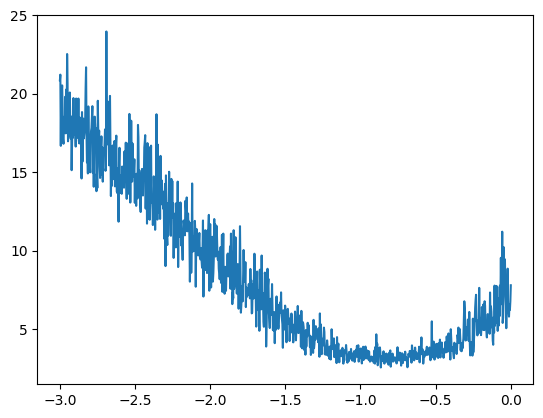

In [250]:
plt.plot(lri, lossi)

从图里可以看到10**-1学习率是比较好的

因此就选择0.1的学习率继续

In [268]:
lri = []
lossi = []

for i in range(10000):

    # minibatch construct
    ix = torch.randint(0,X.shape[0],(32,))  # 从0到X.shape[0](即总的训练样本数)随机生成32个整数，作为mini-batch的索引

    # forward pass
    emb = C[X[ix]]  # 这些索引对应于训练数据中的样本，然后在下面的训练中只使用这些索引对应的数据
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])  # 只计算mini-batch对应的损失
    #print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.001
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    # lri.append(lre[i])
    # lossi.append(loss.item())

#print(loss.item())

In [269]:
emb = C[X]  # 这些索引对应于训练数据中的样本，然后在下面的训练中只使用这些索引对应的数据
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)  # 只计算mini-batch对应的损失
print(loss.item())

2.310551404953003


实际中人们会先找到一个合适的学习率，然后用这个学习率去训练，到最后收尾阶段会逐渐减小学习率(比如说/10),继续训练

然后这里再继续讲点别的

我们现在的模型只有3k的参数，理论上我们可以增加参数，扩充我们的神经网络，使得模型的训练更好，loss更低

但这样会导致模型可能就是只是学会了训练集里的东西，给出的名字都是例子里的，当你用别的名字去评估时，可能loss会非常高

所以在一般的训练过程中，我们会把数据集分成三份，80%训练集(the training split), 10%验证集(the dev split or the validation split),  10%测试集(the test split)

训练集是训练模型参数，验证集是调整超参数，测试集是评估模型表现

In [271]:
# build the dataset

def build_dataset(words):
    block_size = 3 
    X, Y = [], []  
    for w in words:

        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [281]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [328]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [329]:
sum(p.nelement() for p in parameters)

11897

In [330]:
for p in parameters:
    p.requires_grad = True

In [331]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [332]:
lri = []
lossi = []
stepi = []

In [342]:
for i in range(50000):

    # minibatch construct
    ix = torch.randint(0,Xtr.shape[0],(32,))  # 从0到X.shape[0](即总的训练样本数)随机生成32个整数，作为mini-batch的索引

    # forward pass
    emb = C[Xtr[ix]]  # 这些索引对应于训练数据中的样本，然后在下面的训练中只使用这些索引对应的数据
    h = torch.tanh(emb.view(-1,30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])  # 只计算mini-batch对应的损失
    #print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

#print(loss.item())

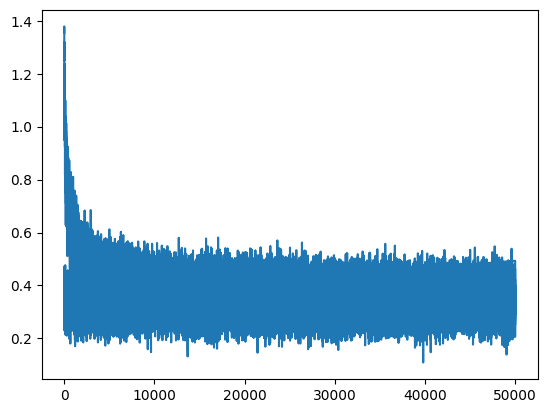

In [343]:
plt.plot(stepi, lossi)

In [344]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1950, grad_fn=<NllLossBackward0>)

In [345]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1695, grad_fn=<NllLossBackward0>)

这里可以可视化看到我们的字母在向量空间的分布情况，这里只展示2个维度

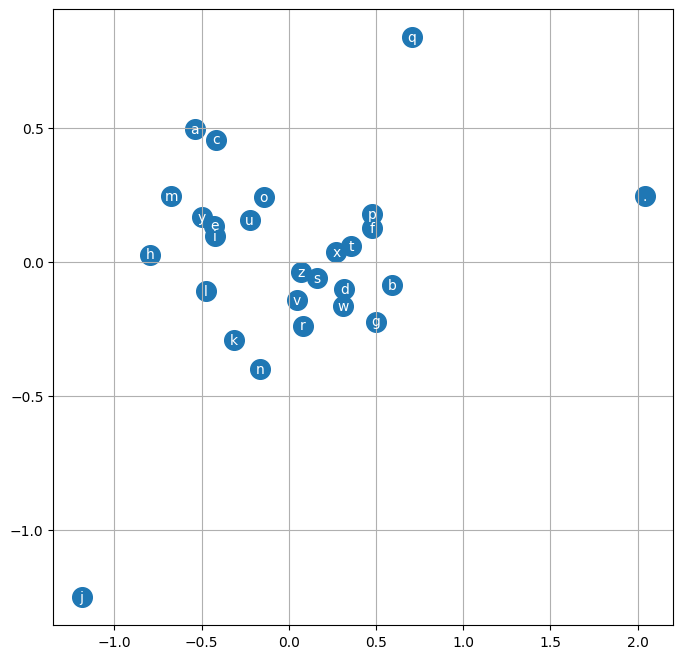

In [346]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data,s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

In [347]:
# sample from the model
g = torch.Generator().manual_seed(2147483647+10)

for _ in range(20):

    out = []
    context = [0] * block_size  # 初始上下文是三个点，表示单词开始
    while True:
        emb = C[torch.tensor([context])]    # 将当前上下文转换为张量，并通过C进行嵌入，得到形状为(1, 3, 10)的张量
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)    # 将嵌入的张量展平为(1, 30)，然后与W1进行矩阵乘法，并加上b1，得到隐藏层的输出h，形状为(1, 200)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

carmah.
amilli.
khi.
mili.
thilahnanden.
jazonen.
deliah.
jareei.
nellara.
chaiiv.
kaleigh.
ham.
jorniquinn.
shovera.
jadbi.
wazell.
dearynix.
kael.
ivuan.
edde.
